## **JURNAL FIX MODUL 2**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

Mengimport library-library seperti NumPy yang digunakan untuk melakukan komputasi numerik dan manipulasi matriks, Matplotlib yang digunakan untuk visualisasi data dalam bentuk grafik atau gambar, dan OpenCV yang dirancang untuk keperluan pengolahan citra (image processing).

Kode dibawah berfungsi melakukan dua hal: pertama, membaca file gambar (Meledak.png) dari folder lokal dan menyimpannya ke dalam variabel. Kedua, menampilkan gambar ke layar agar bisa dilihat. Jadi, satu baris untuk mengambil data gambarnya, dan baris berikutnya untuk memunculkannya secara visual.

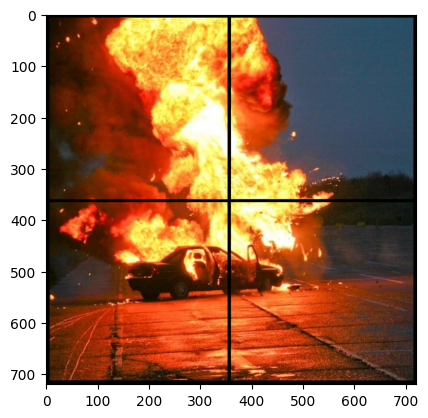

In [2]:
img = plt.imread('Assets/Meledak.png')
plt.imshow(img)

In [3]:
def fungsi_empat_S(gambar, a, b, mode='H'):
 return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

Fungsi diatas berfungsi untuk memotong atau cropping bagian gambar berdasarkan koordinat yang ditentukan. Pada fungsi tersebut mode 'H' dipilih, maka gambar akan dipotong secara horizontal mengikuti rentang baris dari a sampai b. Jadi, fungsi ini mempermudah kita untuk mengambil irisan gambar tertentu sesuai kebutuhan posisi yang diinginkan.

Kode dibawah digunakan untuk membagi satu gambar utuh menjadi empat bagian yang sama besar, seperti potongan puzzle. Pertama, gambar dipotong secara horizontal menjadi bagian atas dan bawah. Setelah itu, masing-masing bagian tersebut dipotong lagi secara vertikal sehingga menghasilkan empat potongan kecil (citra 1 sampai 4). Terakhir, kode ini menampilkan keempat potongan tersebut secara bersamaan dalam satu bingkai berukuran 2x2 agar lebih mudah dibandingkan.

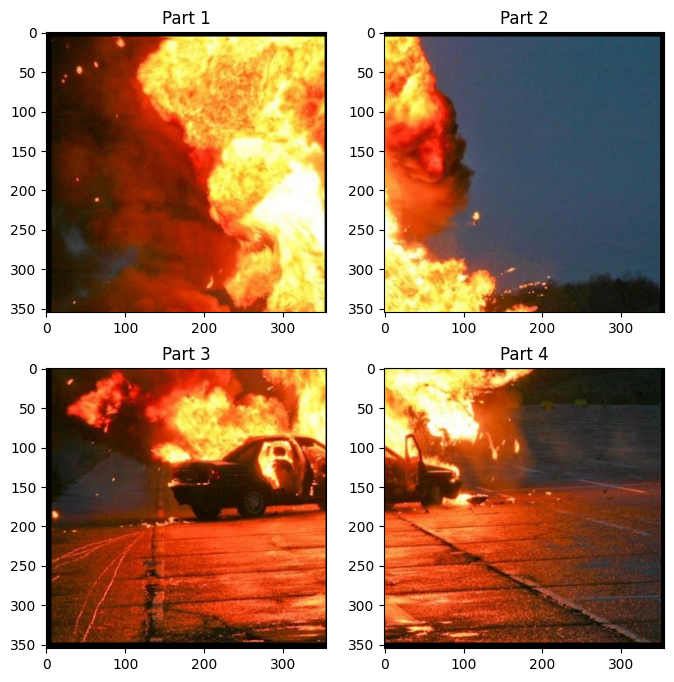

In [ ]:
bagian_atas = fungsi_empat_S(img, 0, 355, mode='H')
bagian_bawah = fungsi_empat_S(img, 365, 730, mode='H')

citra_1 = fungsi_empat_S(bagian_atas, 0, 355, mode='V')
citra_2 = fungsi_empat_S(bagian_atas, 365, 730, mode='V')

citra_3 = fungsi_empat_S(bagian_bawah, 0, 355, mode='V')
citra_4 = fungsi_empat_S(bagian_bawah, 365, 730, mode='V') 


plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.title("Part 1")
plt.imshow(citra_1)

plt.subplot(2, 2, 2)
plt.title("Part 2")
plt.imshow(citra_2)

plt.subplot(2, 2, 3)
plt.title("Part 3")
plt.imshow(citra_3)

plt.subplot(2, 2, 4)
plt.title("Part 4")
plt.imshow(citra_4)

In [5]:
def fungsi_tiga(image, p1=0, p2=0, p3=0, p4=0):
    h, w = image.shape[:2]
    dilated_shape = (h * 2, w * 2) + image.shape[2:]
    dilated = np.zeros(dilated_shape, dtype=image.dtype)
  
    for y in range(h * 2):
        for x in range(w * 2):
            dilated[y, x] = image[int(y / 2), int(x / 2)]
    
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2)
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4)
    hasil = dilated[sy:ey, sx:ex]
    return hasil

Fungsi diatas digunakan untuk memperbesar ukuran gambar menjadi dua kali lipat dari ukuran aslinya melalui proses dilatasi. Cara kerjanya adalah dengan menduplikasi setiap piksel pada gambar asli ke dalam wadah baru yang dimensinya dua kali lebih besar. Selain memperbesar, fungsi ini juga dilengkapi dengan fitur pemotongan (cropping) otomatis di bagian akhir, di mana kita bisa mengatur parameter p1 hingga p4 untuk membuang bagian tepi gambar jika diperlukan. Hasil akhirnya adalah gambar yang tampak lebih besar dengan opsi area yang sudah disesuaikan.

In [ ]:
def crop_hitam(image):
    if image.dtype == float or image.max() <= 1.0:
        image = (image * 255).astype(np.uint8)
    else:
        image = image.astype(np.uint8)
    
    mask = image > 0
    if len(image.shape) == 3:
        mask = np.any(image > 0, axis=2)
        
    baris = np.any(mask, axis=1)
    kolom = np.any(mask, axis=0)
    
    if not np.any(baris) or not np.any(kolom):
        return image
    
    y1, y2 = np.where(baris)[0][[0, -1]]
    x1, x2 = np.where(kolom)[0][[0, -1]]
    return image[y1:y2+1, x1:x2+1]

Fungsi diatas gunanya untuk membuang pinggiran hitam yang tidak terpakai pada sebuah gambar. Caranya, kode akan mendeteksi piksel mana saja yang memiliki warna (di atas nol) untuk menentukan batas konten asli gambar tersebut. Setelah batas atas, bawah, kiri, dan kanannya ketemu, fungsi akan memotong gambar tepat pada area yang ada isinya saja. Jadi, hasil akhirnya adalah gambar yang lebih padat dan bersih karena bagian hitam di sekelilingnya sudah dihapus otomatis.

Kode dibawah melakukan proses perbesaran dan pembersihan pada keempat potongan gambar yang sudah dibuat sebelumnya. Pertama, setiap potongan gambar diperbesar ukurannya menggunakan fungsi_tiga dengan tambahan sedikit pemangkasan pada bagian tepinya. Setelah diperbesar, gambar-gambar tersebut diproses lagi menggunakan fungsi crop_hitam untuk memastikan tidak ada area kosong atau pinggiran hitam yang mengganggu. Terakhir, hasilnya ditampilkan kembali dalam satu bingkai berukuran 2x2 agar kita bisa melihat hasil perbesaran yang lebih bersih dan fokus pada konten utamanya.

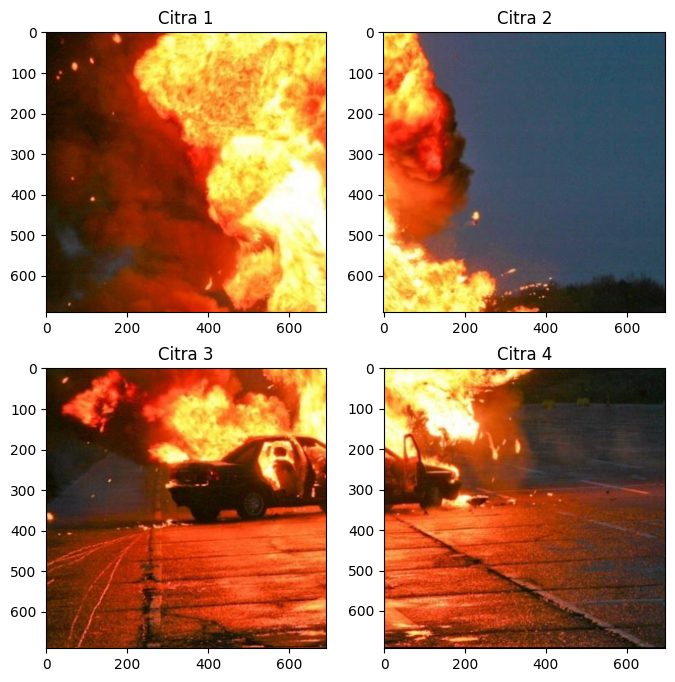

In [7]:
citra1_dilated = fungsi_tiga(citra_1, p1=5, p2=5, p3=5, p4=5)
citra2_dilated = fungsi_tiga(citra_2, p1=5, p2=5, p3=5, p4=5)
citra3_dilated = fungsi_tiga(citra_3, p1=5, p2=5, p3=5, p4=5)
citra4_dilated = fungsi_tiga(citra_4, p1=5, p2=5, p3=5, p4=5)

citra1_cut = crop_hitam(citra1_dilated)
citra2_cut = crop_hitam(citra2_dilated)
citra3_cut = crop_hitam(citra3_dilated)
citra4_cut = crop_hitam(citra4_dilated)

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.title("Citra 1")
plt.imshow(citra1_cut)

plt.subplot(2, 2, 2)
plt.title("Citra 2")
plt.imshow(citra2_cut)

plt.subplot(2, 2, 3)
plt.title("Citra 3")
plt.imshow(citra3_cut)

plt.subplot(2, 2, 4)
plt.title("Citra 4")
plt.imshow(citra4_cut)

In [8]:
def merge_image(citra1, citra2, orientation='H'):
    has_channels = len(citra1.shape) == 3
    
    if orientation == 'H':
        tinggi = max(citra1.shape[0], citra2.shape[0])
        lebar_total = citra1.shape[1] + citra2.shape[1]
        
        if not has_channels:
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype)
        else:
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype)

        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1
        gabungan[0:citra2.shape[0], citra1.shape[1]:] = citra2
        
    else:
        lebar = max(citra1.shape[1], citra2.shape[1])
        tinggi_total = citra1.shape[0] + citra2.shape[0]
        
        if not has_channels:
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype)
        else:
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype)
        
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1
        gabungan[citra1.shape[0]:, 0:citra2.shape[1]] = citra2
        
    return gabungan

Fungsi diatas digunakan untuk menggabungkan dua gambar menjadi satu kesatuan. Kita bisa memilih arah penggabungannya: jika mode 'H' dipilih, kedua gambar akan disusun berdampingan secara horizontal (kiri-kanan), sedangkan jika memilih mode lain, gambar akan disusun menumpuk secara vertikal (atas-bawah). Fungsi ini juga otomatis menyiapkan "wadah" kosong yang ukurannya pas dengan total dimensi kedua gambar tersebut, lalu menempelkan masing-masing gambar ke posisinya sehingga menjadi satu citra utuh yang baru.

Bagian kode dibawah berfungsi untuk menyusun kembali potongan-potongan gambar yang sebelumnya sudah diperbesar dan dibersihkan menjadi satu gambar utuh. Prosesnya dilakukan secara bertahap: pertama, potongan kiri dan kanan digabungkan secara mendatar (horizontal) untuk membentuk baris atas dan baris bawah. Setelah kedua baris tersebut jadi, keduanya kemudian ditumpuk secara tegak (vertikal) hingga membentuk kembali komposisi gambar yang lengkap. Terakhir, gambar yang sudah bersatu tersebut ditampilkan ke layar menggunakan perintah imshow

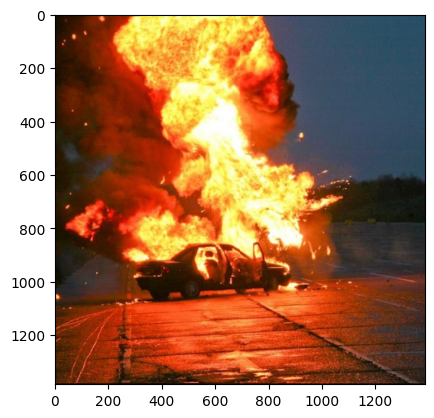

In [9]:
citra1_M = merge_image(citra1_cut, citra2_cut, orientation='H')
citra2_M = merge_image(citra3_cut, citra4_cut, orientation='H')
citra_gabungan = merge_image(citra1_M, citra2_M, orientation='V')
citra_gabungan = citra_gabungan.astype(np.uint8)
plt.imshow(citra_gabungan)

Kode dibawah digunakan untuk mengubah gambar yang sebelumnya berwarna menjadi format hitam-putih atau grayscale. Pertama, fungsi cvtColor dari OpenCV mengubah ruang warna gambar dari RGB ke abu-abu, kemudian hasilnya ditampilkan menggunakan skema warna abu-abu (cmap='gray'). Untuk memberikan tampilan yang lebih bersih, perintah plt.axis('off') ditambahkan untuk menyembunyikan angka-angka koordinat atau garis pada sumbu grafik.

(np.float64(-0.5), np.float64(1385.5), np.float64(1383.5), np.float64(-0.5))

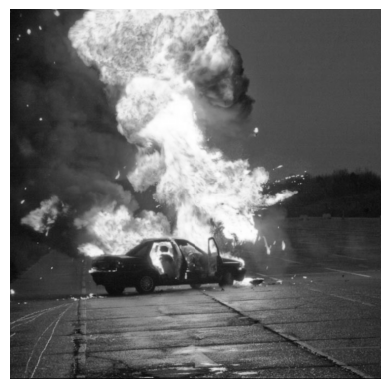

In [10]:
img2 = cv2.cvtColor(citra_gabungan, cv2.COLOR_RGB2GRAY)
plt.imshow(img2, cmap='gray')
plt.axis('off')

In [11]:
def ekualisasi(citra):
    height, width = citra.shape

    hist = np.zeros(256, dtype=int)
    for y in range(height):
        for x in range(width):
            nilai_pixel = citra[y, x]
            hist[nilai_pixel] += 1
            
    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]
        
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)
    
    hasil = np.zeros_like(citra, dtype=np.uint8)
    for y in range(height):
        for x in range(width):
            hasil[y, x] = cdf_normal[citra[y, x]]
            
    return hasil

Fungsi diatas digunakan untuk meningkatkan kontras gambar secara otomatis melalui teknik ekualisasi histogram. Cara kerjanya adalah dengan menghitung penyebaran warna (piksel) yang ada, lalu meratakannya agar bagian yang terlalu gelap atau terlalu terang menjadi lebih jelas terlihat. Prosesnya dimulai dengan menghitung kemunculan tiap warna, menjumlahkannya, dan memetakan kembali warna-warna tersebut ke posisi yang baru agar distribusi cahayanya lebih seimbang.

Kode dibawah menerapkan fungsi ekualisasi yang sudah dibuat sebelumnya ke dalam gambar hitam-putih. Langkah pertama adalah mengubah skala nilai piksel gambar menjadi rentang 0-255 agar sesuai dengan format standar pengolahan citra. Setelah itu, gambar diproses menggunakan fungsi ekualisasi untuk mempertajam kontras dan memperjelas detail citra sebelumnya. Terakhir, hasilnya ditampilkan kembali dalam format abu-abu tanpa menyertakan garis sumbu koordinat.

(np.float64(-0.5), np.float64(1385.5), np.float64(1383.5), np.float64(-0.5))

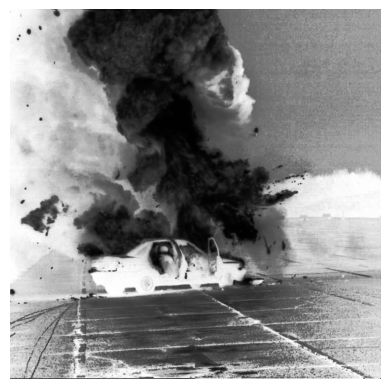

In [12]:
img2_n = (img2 * 255).astype(int)
citra_ekualisasi = ekualisasi(img2_n)

plt.imshow(citra_ekualisasi, cmap='gray')
plt.axis('off')

In [13]:
def buat_hist(citra):
    histogram = [0] * 256
    
    height = len(citra)
    width = len(citra[0])
    
    for i in range(height):
        for j in range(width):
            val = int(citra[i][j])
            histogram[val] += 1
            
    return histogram

def plot_gabungan(hist_sebelum, hist_sesudah, title):
    plt.figure(figsize=(10, 5))
    plt.title(title)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    
    plt.bar(range(256), hist_sebelum, color='green', alpha=0.6, label='Histogram Sebelum Ekualisasi')
    plt.bar(range(256), hist_sesudah, color='red', alpha=0.6, label='Histogram Sesudah Ekualisasi')
    
    plt.legend()

Bagian kode diatas terdiri dari dua fungsi yang digunakan untuk menganalisis penyebaran warna pada gambar dalam bentuk grafik. Fungsi pertama, "buat_hist" bertugas menghitung berapa kali setiap nilai warna (dari 0 sampai 255) muncul di dalam gambar. Kemudian, fungsi "plot_gabungan" digunakan untuk menampilkan hasil perhitungan tersebut ke dalam satu grafik batang agar kita bisa membandingkan perbedaan distribusi warna antara gambar asli (berwarna hijau) dan gambar hasil ekualisasi (berwarna merah).

Kode dibawah digunakan untuk memproses dan membandingkan data statistik warna antara gambar asli dan gambar yang sudah ditingkatkan kontrasnya. Pertama, program menghitung distribusi nilai piksel untuk gambar awal dan gambar hasil ekualisasi menggunakan fungsi buat_hist. Setelah itu, fungsi plot_gabungan memvisualisasikan keduanya ke dalam satu grafik histogram. Tujuannya adalah untuk membuktikan secara data bahwa proses ekualisasi telah berhasil menyebarkan intensitas piksel secara lebih merata ke seluruh rentang warna, sebagaimana yang terlihat dari pergeseran batang grafik merah dibandingkan grafik hijau. Hasil Penerapan ekualisasi histogram berhasil mengubah citra asli yang kusam menjadi lebih tajam dengan meratakan distribusi piksel yang tadinya menumpuk (grafik hijau) ke seluruh rentang warna (grafik merah). Hal ini meningkatkan kontras sehingga detail yang sebelumnya tersembunyi pada area gelap maupun terang, seperti tekstur ledakan dan bayangan mobil, sekarang terlihat jauh lebih jelas dan seimbang secara visual.

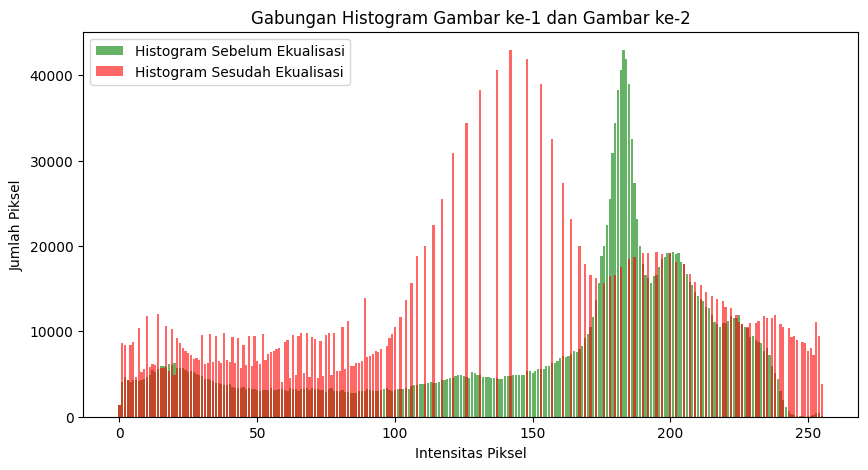

In [14]:
hist_data = buat_hist(img2 * 255)
hist_ekualisasi = buat_hist(citra_ekualisasi)
plot_gabungan(hist_data, hist_ekualisasi, "Gabungan Histogram Gambar ke-1 dan Gambar ke-2")

Kode dibawah berfungsi untuk membaca sebuah file gambar bernama 'Windut.png' dari folder 'Assets' dan langsung mengubahnya menjadi format hitam-putih (grayscale). Menggunakan fungsi imread dari OpenCV, gambar asli diambil, lalu dikonversi menggunakan cvtColor agar tidak memiliki warna (hanya derajat keabuan), dan terakhir ditampilkan ke layar menggunakan skema warna abu-abu.

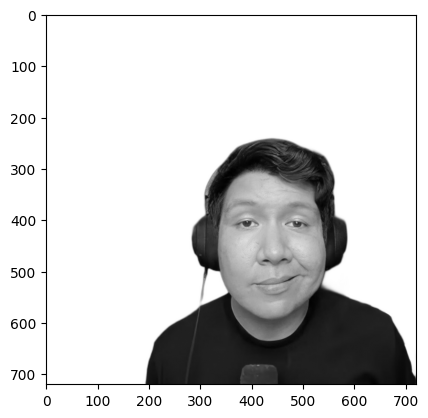

In [15]:
citra_windut = cv2.cvtColor(cv2.imread('Assets/Windut.png'), cv2.COLOR_BGR2GRAY)
plt.imshow(citra_windut, cmap='gray')

Seperti sebelumnya, kode dibawah berfungsi untuk membaca sebuah file gambar bernama 'Bunga.png' dari folder 'Assets' dan langsung mengubahnya menjadi format hitam-putih (grayscale). Menggunakan fungsi imread dari OpenCV, gambar asli diambil, lalu dikonversi menggunakan cvtColor agar tidak memiliki warna (hanya derajat keabuan), dan terakhir ditampilkan ke layar menggunakan skema warna abu-abu.

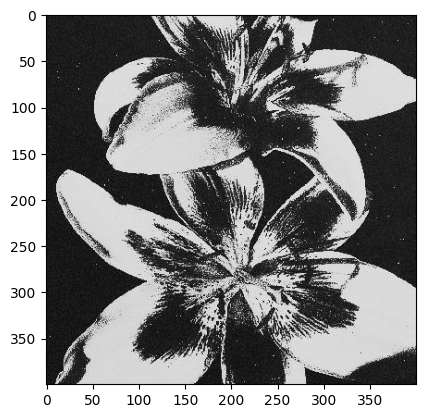

In [16]:
citra_bunga = cv2.cvtColor(cv2.imread('Assets/Bunga.png'), cv2.COLOR_BGR2GRAY)
plt.imshow(citra_bunga, cmap='gray')

In [17]:
def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal = np.zeros(256, dtype=int)
    h_asal, w_asal = citra_asal.shape
    for y in range(h_asal):
        for x in range(w_asal):
            val = int(citra_asal[y, x])
            hist_asal[val] += 1
            
    hist_target = np.zeros(256, dtype=int)
    h_target, w_target = citra_target.shape
    for y in range(h_target):
        for x in range(w_target):
            val = int(citra_target[y, x])
            hist_target[val] += 1
            
    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)
    
    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]
    
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i-1] + hist_asal[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]
        
    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]
    
    map_hist = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        selisih_terkecil = 1.0
        index_terbaik = 0
        for j in range(256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < selisih_terkecil:
                selisih_terkecil = selisih
                index_terbaik = j
        map_hist[i] = index_terbaik
        
    hasil = np.zeros((h_asal, w_asal), dtype=np.uint8)
    for y in range(h_asal):
        for x in range(w_asal):
            nilai_lama = int(citra_asal[y, x])
            hasil[y, x] = map_hist[nilai_lama]
            
    return hasil

Fungsi diatas menjalankan teknik Histogram Matching untuk memaksa citra asal meniru karakteristik visual citra target dengan cara menghitung dan menormalisasi distribusi kumulatif (CDF) dari kedua gambar tersebut. Melalui proses pemetaan piksel, setiap nilai warna pada citra asal dicocokkan dengan nilai pada citra target yang memiliki persentase kumulatif paling serupa, lalu nilai tersebut diterapkan kembali untuk membentuk citra baru. Hasil akhirnya adalah sebuah gambar yang tetap mempertahankan struktur objek aslinya, namun kini memiliki nuansa pencahayaan, kontras, dan distribusi intensitas yang identik dengan citra referensi yang digunakan.

Kode dibawah berfungsi menyiapkan dua gambar, yaitu citra_windut dan citra_bunga, dengan memastikan setiap nilai pikselnya dibulatkan ke angka bulat terdekat agar siap diproses. Setelah kedua gambar dalam kondisi siap, fungsi spesifikasi_histogram dipanggil untuk mengubah karakteristik visual gambar windut_ready agar mengikuti pola pencahayaan dan kontras dari bunga_ready. Hasil akhir dari transformasi tersebut kemudian ditampilkan sebagai gambar baru dengan judul "Hasil spesifikasi" dalam format skala abu-abu.

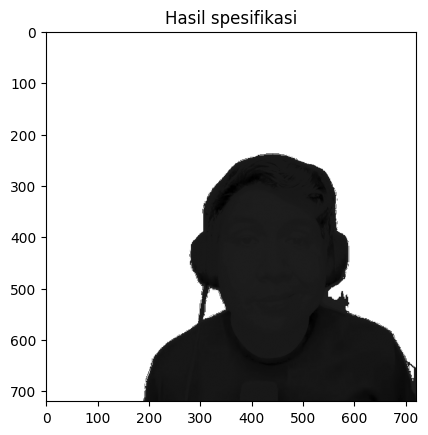

In [18]:
h1, w1 = citra_windut.shape[:2]
windut_ready = np.zeros((h1, w1))

for i in range(h1):
    for j in range(w1):
        windut_ready[i, j] = int(np.round(citra_windut[i, j]))

h2, w2 = citra_bunga.shape[:2]
bunga_ready = np.zeros((h2, w2))

for i in range(h2):
    for j in range(w2):
        bunga_ready[i, j] = int(np.round(citra_bunga[i, j]))

hasil_batubara = spesifikasi_histogram(windut_ready, bunga_ready)

plt.imshow(hasil_batubara, cmap='gray')
plt.title("Hasil spesifikasi")

plt.show()


In [19]:
def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5))
    plt.title(title)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    
    plt.bar(range(256), histogram, color=ImgColor)
    
    plt.show()

Fungsi diatas dirancang untuk memvisualisasikan sebaran warna sebuah gambar ke dalam bentuk grafik batang (histogram). Dengan menerima data histogram, judul grafik, dan pilihan warna sebagai input, fungsi ini akan membuat diagram yang menunjukkan jumlah piksel untuk setiap tingkat intensitas warna dari 0 hingga 255.

Kode dibawah berfungsi untuk menghitung dan memvisualisasikan distribusi warna akhir dari gambar "Windut" yang telah dimodifikasi dalam bentuk grafik. Pertama, fungsi buat_hist digunakan untuk menghitung jumlah kemunculan setiap nilai piksel pada hasil_batubara. Kemudian, fungsi plot_histogram menampilkan data tersebut ke dalam grafik batang berwarna merah dengan judul "Spesifikasi Windut dengan Bunga". Grafik ini secara teknis menunjukkan bahwa distribusi warna gambar "Windut" kini telah berubah dan mengikuti pola karakteristik (spesifikasi) dari gambar "Bunga".

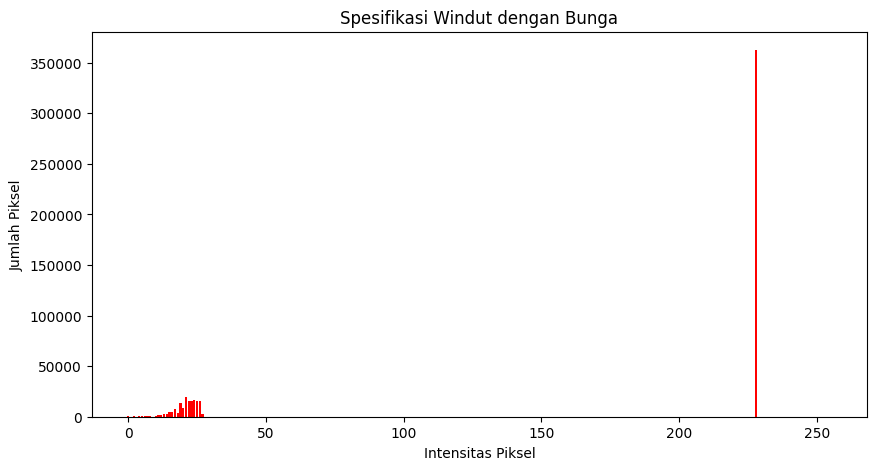

In [20]:
h_batubara = buat_hist(hasil_batubara)
plot_histogram(h_batubara, "Spesifikasi Windut dengan Bunga", "red")

Kode dibawah melakukan teknik Image Masking untuk menggabungkan dua gambar dengan cara memetakan koordinat gambar ledakan agar sesuai dengan dimensi target 720 x 720 piksel, lalu menerapkan logika seleksi piksel berdasarkan ambang batas intensitas. Jika piksel pada gambar "Windut" memiliki nilai di bawah 200 (area gelap/objek), maka nilai tersebut dipertahankan, namun jika nilainya di atas 200 (area terang/latar belakang), posisinya akan digantikan oleh piksel dari citra ledakan. Proses ini diakhiri dengan pembulatan nilai piksel ke bilangan bulat terdekat untuk memastikan validitas data sebelum ditampilkan, sehingga menghasilkan komposisi visual di mana objek utama dari satu gambar seolah-olah berpindah ke latar belakang gambar lainnya.

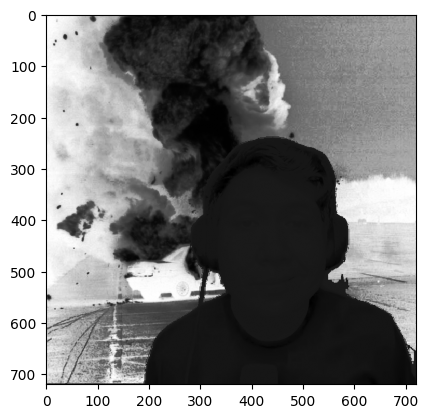

In [21]:
h_crop, w_crop = 720, 720
h_ledakan, w_ledakan = citra_ekualisasi.shape[:2]

hasil_masking = np.zeros((h_crop, w_crop))

for y in range(h_crop):
    for x in range(w_crop):
        y_latar = int(y * (h_ledakan / h_crop))
        x_latar = int(x * (w_ledakan / w_crop))
        
        if y_latar >= h_ledakan: y_latar = h_ledakan - 1
        if x_latar >= w_ledakan: x_latar = w_ledakan - 1
        
        pixel_windut = hasil_batubara[y, x]
        pixel_latar = citra_ekualisasi[y_latar, x_latar] 
        if pixel_windut < 200: 
            hasil_masking[y, x] = pixel_windut
        else:
            hasil_masking[y, x] = pixel_latar

for y in range(h_crop):
    for x in range(w_crop):
        hasil_masking[y, x] = int(np.round(hasil_masking[y, x]))

plt.imshow(hasil_masking, cmap='gray')
plt.show()

Kode dibawah melakukan teknik Image Masking untuk menyatukan objek dari citra_windut ke latar belakang citra_ekualisasi dengan menyesuaikan skala dimensi melalui perhitungan row_ratio dan col_ratio. Dalam prosesnya, setiap piksel pada citra objek diperiksa, jika nilai intensitasnya di bawah 240 (dianggap sebagai area objek), maka piksel asli tersebut dipertahankan, namun jika nilainya 240 atau lebih (dianggap sebagai latar belakang putih), posisinya digantikan oleh piksel dari citra ledakan yang sudah dipetakan koordinatnya. Langkah terakhir adalah melakukan pembulatan nilai piksel ke bilangan bulat terdekat untuk memastikan validitas format citra sebelum akhirnya ditampilkan sebagai satu kesatuan gambar grayscale yang baru.

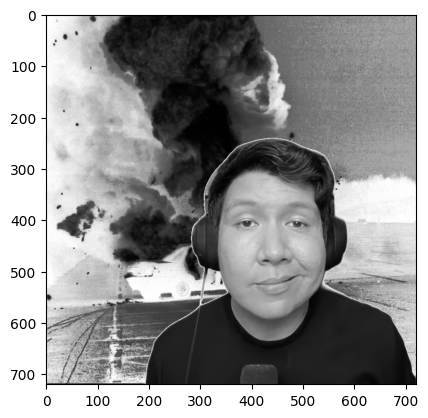

In [22]:
h_w, w_w = citra_windut.shape[:2]
h_l, w_l = citra_ekualisasi.shape[:2] 
hasil_akhir = np.zeros((h_w, w_w))

row_ratio = h_l / h_w
col_ratio = w_l / w_w

for y in range(h_w):
    for x in range(w_w):

        y_latar = int(y * row_ratio)
        x_latar = int(x * col_ratio)
        
        if y_latar >= h_l: y_latar = h_l - 1
        if x_latar >= w_l: x_latar = w_l - 1

        pixel_windut_asli = citra_windut[y, x]
        pixel_latar = citra_ekualisasi[y_latar, x_latar]
        
        if pixel_windut_asli < 240: 
            hasil_akhir[y, x] = pixel_windut_asli
        else:
            hasil_akhir[y, x] = pixel_latar

for y in range(h_w):
    for x in range(w_w):
        hasil_akhir[y, x] = int(np.round(hasil_akhir[y, x]))

plt.imshow(hasil_akhir, cmap='gray')
plt.show()

Kode dibawah digunakan untuk mengubah gambar yang awalnya berwarna menjadi format hitam-putih atau grayscale. Pertama, fungsi cvtColor dari OpenCV mengubah ruang warna gambar dari RGB ke abu-abu, kemudian hasilnya ditampilkan menggunakan skema warna abu-abu (cmap='gray'). Untuk memberikan tampilan yang lebih bersih, perintah plt.axis('off') ditambahkan untuk menyembunyikan angka-angka koordinat atau garis pada sumbu grafik.

(np.float64(-0.5), np.float64(734.5), np.float64(489.5), np.float64(-0.5))

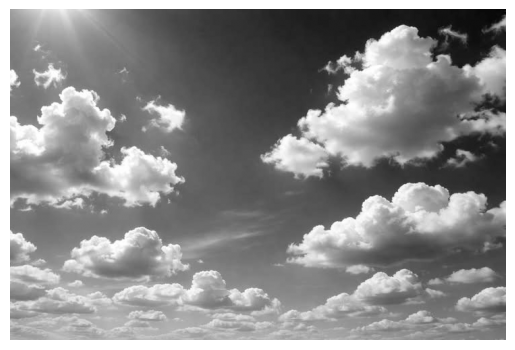

In [23]:
citra_langit = cv2.cvtColor(cv2.imread('Assets/Langit.png'), cv2.COLOR_BGR2GRAY)
plt.imshow(citra_langit, cmap='gray')
plt.axis('off')

Kode dibawah melakukan tahap spesifikasi dengan menerapkan kembali fungsi spesifikasi_histogram pada gambar hasil_akhir (hasil penggabungan sebelumnya) menggunakan citra_langit sebagai referensi target. Proses ini bertujuan untuk menyelaraskan nuansa pencahayaan dan distribusi intensitas dari gambar hasil masking agar mengikuti karakteristik visual langit, sehingga transisi antara objek dan latar belakang tampak lebih menyatu. Setelah transformasi distribusi warna selesai, hasilnya ditampilkan dalam format skala abu-abu menggunakan plt.imshow.

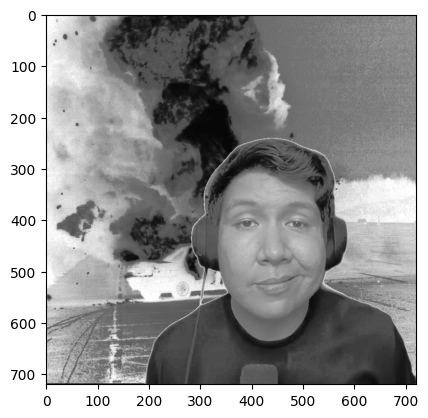

In [24]:
hasil_finalisasi= spesifikasi_histogram(hasil_akhir, citra_langit)
plt.imshow(hasil_finalisasi, cmap='gray')

Kode dibawah berfungsi untuk menghitung distribusi frekuensi intensitas piksel pada citra hasil_finalisasi menggunakan fungsi buat_hist. Setelah data diperoleh, fungsi plot_histogram akan memvisualisasikannya ke dalam bentuk grafik batang berwarna merah dengan judul "Spesifikasi Windut dengan Langit". Grafik ini merepresentasikan hasil akhir dari seluruh rangkaian proses, yang menunjukkan bagaimana sebaran cahaya pada gambar gabungan telah berhasil disesuaikan agar mengikuti pola distribusi intensitas dari citra langit sebagai referensi target.

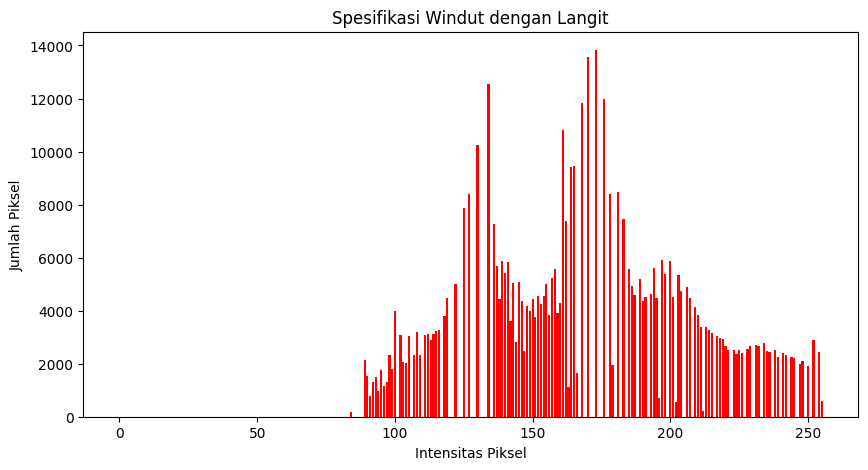

In [25]:
h_windut_ganteng = buat_hist(hasil_finalisasi)
plot_histogram(h_windut_ganteng, "Spesifikasi Windut dengan Langit", "red")

In [26]:
h, w = citra_gabungan.shape[:2]
citra_ledakan_biru = np.zeros((h, w, 3), dtype=np.uint8)

for y in range(h):
    for x in range(w):

        if len(citra_gabungan.shape) == 2:
            pixel_val = citra_gabungan[y, x]

            citra_ledakan_biru[y, x, 0] = int(pixel_val * 0.1) 
            citra_ledakan_biru[y, x, 1] = int(pixel_val * 0.3) 
            citra_ledakan_biru[y, x, 2] = pixel_val           
        else:
            r, g, b = citra_gabungan[y, x]
            citra_ledakan_biru[y, x, 0] = b 
            citra_ledakan_biru[y, x, 1] = g 
            citra_ledakan_biru[y, x, 2] = r 

Kode diatas bertujuan untuk memberikan efek pewarnaan biru pada citra gabungan dengan cara memanipulasi saluran warna RGB secara manual. Jika input berupa citra grayscale, setiap piksel diubah menjadi format tiga saluran (RGB) di mana intensitas biru (B) dibiarkan penuh, sementara intensitas merah (R) dan hijau (G) dikurangi secara drastis untuk menciptakan nuansa biru yang dominan. Jika citra sudah memiliki format warna, kode ini akan menukar posisi saluran warna merah dan biru (dari RGB menjadi BGR), yang mengubah tampilan warna asli menjadi skema warna yang berbeda.

Kode dibawah melakukan penggabungan citra berwarna secara manual dengan menyatukan objek dari windut_bgr ke latar belakang citra_gabungan yang telah diberi efek warna biru. Proses diawali dengan penyelarasan skala dimensi latar belakang agar sesuai dengan ukuran target 720 x 720 piksel, diikuti dengan transformasi warna pada latar belakang di mana piksel grayscale diubah menjadi nuansa biru. Logika masking kemudian diterapkan dengan menghitung rata-rata intensitas setiap piksel pada gambar objek, dimana jika rata-rata tersebut di bawah 240, maka piksel asli dari windut_bgr dipertahankan, namun jika di atas 240 (area putih/latar belakang), posisinya digantikan oleh piksel latar belakang yang sudah dibiru-birukan tadi. Hasil akhirnya ditampilkan sebagai komposisi visual berwarna biru dominan dengan judul "Windut Cipularang" tanpa sumbu koordinat.

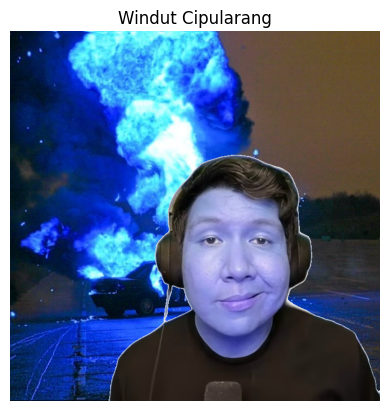

In [27]:
windut_bgr = cv2.imread('Assets/Windut.png')
h_w, w_w = 720, 720
h_g, w_g = citra_gabungan.shape[:2] 

hasil_akhir = np.zeros((h_w, w_w, 3), dtype=np.uint8)
r_ratio = h_g / h_w
c_ratio = w_g / w_w

for y in range(h_w):
    for x in range(w_w):
        y_g = int(y * r_ratio)
        x_g = int(x * c_ratio)

        y_g = min(y_g, h_g - 1)
        x_g = min(x_g, w_g - 1)

        p_gabung = citra_gabungan[y_g, x_g]
        
        if len(citra_gabungan.shape) == 2: 
            p_latar_biru = [int(p_gabung * 0.1), int(p_gabung * 0.3), p_gabung]
        else: 
            r, g, b = p_gabung
            p_latar_biru = [b, g, r]
            
        p_win = windut_bgr[y, x]
        if (int(p_win[0]) + int(p_win[1]) + int(p_win[2])) / 3 < 240:
            hasil_akhir[y, x] = p_win
        else:
            hasil_akhir[y, x] = p_latar_biru

plt.imshow(hasil_akhir)
plt.title("Windut Cipularang")
plt.axis('off')
plt.show()

#### **Kesimpulan**

Melalui praktikum Modul 2 tentang Ekualisasi dan Spesifikasi Histogram ini, saya telah mempelajari bagaimana mengontrol pencahayaan dan kontras sebuah gambar secara teknis. Dengan teknik Ekualisasi, saya bisa memperbaiki gambar yang terlalu gelap atau terlalu terang agar detailnya terlihat lebih jelas. Sementara melalui Spesifikasi Histogram, saya belajar cara menularkan/berbagi komposisi warna dari satu gambar ke gambar lainnya sehingga keduanya memiliki kemiripan visual.

Hasil praktikum ini berkaitan erat dengan ketercapaian CPMK, di mana saya tidak hanya sekadar ngoding, tetapi memahami bagaimana memanipulasi angka-angka di dalam matriks gambar untuk mengubah tampilannya. Penggabungan objek (masking) dan pemberian warna biru pada hasil akhir membuktikan bahwa pemahaman tentang intensitas piksel sangat penting untuk menciptakan komposisi gambar yang pas. Yang pada intinya, modul ini memberikan keahlian dasar dalam memperbaiki kualitas gambar dan memodifikasi elemen visual sesuai dengan kebutuhan yang diinginkan.